In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os 
import seaborn as sns

In [6]:
def data_corrector(symbol):
    path = '../updatedtop20datasets/'
    filepath = f'{path}{symbol}.parquet'
    if not os.path.exists(filepath):
        print(f"There is no such file for the symbol {symbol}")
        return None
    data = pd.read_parquet(filepath)
    data = data.loc[:, ~data.columns.str.contains('Unnamed')]
    data['date'] = pd.to_datetime(data['date'])
    if data.isna().sum().sum() > 0:
        print(f"Missing Values Detected for symbol {symbol}, Fixed using forward fill")
        data = data.ffill()
    if data.duplicated().sum() > 0:
        data = data.drop_duplicates()
        print(f"There are duplicate values for stock {symbol}. Fixed using duplication drop")
    data.to_parquet(filepath, index = False)
    return data



In [7]:
### Creating datasets for the top 20 companies 
watchlist = {
    "AAPL":  "Apple",
    "MSFT":  "Microsoft", 
    "NVDA":  "Nvidia",
    "GOOGL": "Alphabet (Google)",
    "AMD":  "AMD",
    "META":  "Meta (Facebook)",
    "TSLA":  "Tesla",
    "NFLX": "Netflix",
    "LLY":   "Eli Lilly",
    "AVGO":   "Broadcom",
    "MU":    "Micron Technology",
    "QCOM":   "Qualcomm",
    "UNH":   "UnitedHealth",
    "WMT":   "Walmart",
    "MA":    "Mastercard",
    "JNJ":   "Johnson & Johnson",
    "PG":    "Procter & Gamble",
    "HD":    "Home Depot",
    "ORCL":  "Oracle",
    "JPM": "JPMorgan Chase"
}



In [8]:
### Data preprocessing for all the files 
for key,value in watchlist.items():
    data_corrector(key)

### Problem statements: Like I create a parquet file in one notebook and try to update it in the other notebook why does not it update

In [12]:
data = data_corrector("AAPL")
data.head(5)

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor,Symbol
0,2008-01-02 00:00:00+00:00,194.84,200.26,192.55,199.27,38542100,5.832436,5.994681,5.763886,5.965046,1079179879,0.0,1.0,AAPL
1,2008-01-03 00:00:00+00:00,194.93,197.39,192.69,195.41,30073800,5.835131,5.908769,5.768077,5.849499,842067242,0.0,1.0,AAPL
2,2008-01-04 00:00:00+00:00,180.05,193.00,178.89,191.45,51994000,5.389705,5.777357,5.354981,5.730959,1455833455,0.0,1.0,AAPL
3,2008-01-07 00:00:00+00:00,177.64,183.60,170.23,181.25,74006900,5.317563,5.495973,5.095749,5.425627,2072195272,0.0,1.0,AAPL
4,2008-01-08 00:00:00+00:00,171.25,182.46,170.80,180.14,54422000,5.126282,5.461847,5.112811,5.392399,1523817523,0.0,1.0,AAPL


---
### Features Explanation 
### 1. adjClose = 

---
### Creating the new features out of the given columns 


In [63]:
def new_features(symbol):
    path = '../updatedtop20datasets/'
    file_path = f'{path}{symbol}.parquet'
    data = pd.read_parquet(file_path)
    data['price_return'] = data['adjClose'].diff() / data['adjClose'].shift(1)
    data['price_return'] = data['price_return'].fillna(0)
    data['Volatility_7Days'] = data['adjClose'].rolling(window = 7).std().fillna(0)
    data['Volatility_30Days'] = data['adjClose'].rolling(window = 30).std().fillna(0)
    data['Price_Swing'] = (data['adjHigh'] - data['adjHigh']) / data['adjClose']
    data['volume_zscore7Days'] = (data['volume'] - data['volume'].rolling(window=7).mean()) / data['volume'].rolling(window=7).std()
    data['volume_zscore7Days'] = data['volume_zscore7Days'].fillna(0)
    data['volume_zscore30Days'] = (data['adjVolume'] - data['adjVolume'].rolling(window=30).mean()) / data['adjVolume'].rolling(window=30).std()
    data['volume_zscore30Days'] = data['volume_zscore30Days'].fillna(0)
    ### Calculating the MASignal
    data['7Day'] = data['adjClose'].rolling(window=7).mean()
    data['30Day'] = data['adjClose'].rolling(window=30).mean()
    data['MASignal'] = (data['7Day'] > data['30Day']).astype(int)
    data = data.drop(columns = ['7Day', '30Day'])
    return data
    

In [62]:
data = new_features("AAPL")
data.head(10)

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,divCash,splitFactor,Symbol,price_return,Volatility_7Days,Volatility_30Days,Price_Swing,volume_zscore7Days,volume_zscore30Days,MASignal
0,2008-01-02 00:00:00+00:00,194.84,200.26,192.55,199.27,38542100,5.832436,5.994681,5.763886,5.965046,...,0.0,1.0,AAPL,0.000000,0.000000,0.0,0.0,0.000000,0.0,0
1,2008-01-03 00:00:00+00:00,194.93,197.39,192.69,195.41,30073800,5.835131,5.908769,5.768077,5.849499,...,0.0,1.0,AAPL,0.000462,0.000000,0.0,0.0,0.000000,0.0,0
2,2008-01-04 00:00:00+00:00,180.05,193.00,178.89,191.45,51994000,5.389705,5.777357,5.354981,5.730959,...,0.0,1.0,AAPL,-0.076335,0.000000,0.0,0.0,0.000000,0.0,0
3,2008-01-07 00:00:00+00:00,177.64,183.60,170.23,181.25,74006900,5.317563,5.495973,5.095749,5.425627,...,0.0,1.0,AAPL,-0.013385,0.000000,0.0,0.0,0.000000,0.0,0
4,2008-01-08 00:00:00+00:00,171.25,182.46,170.80,180.14,54422000,5.126282,5.461847,5.112811,5.392399,...,0.0,1.0,AAPL,-0.035972,0.000000,0.0,0.0,0.000000,0.0,0
5,2008-01-09 00:00:00+00:00,179.40,179.50,168.30,171.30,64781500,5.370248,5.373241,5.037975,5.127778,...,0.0,1.0,AAPL,0.047591,0.000000,0.0,0.0,0.000000,0.0,0
6,2008-01-10 00:00:00+00:00,178.02,181.00,175.41,177.58,52963400,5.328938,5.418143,5.250809,5.315767,...,0.0,1.0,AAPL,-0.007692,0.271172,0.0,0.0,0.038211,0.0,0
7,2008-01-11 00:00:00+00:00,172.69,177.85,170.00,176.00,44010200,5.169387,5.323849,5.088864,5.268471,...,0.0,1.0,AAPL,-0.029940,0.231091,0.0,0.0,-0.651221,0.0,0
8,2008-01-14 00:00:00+00:00,178.78,179.42,175.17,177.52,39301800,5.351688,5.370847,5.243625,5.313971,...,0.0,1.0,AAPL,0.035266,0.103063,0.0,0.0,-1.287387,0.0,0
9,2008-01-15 00:00:00+00:00,169.04,179.22,164.66,177.72,83688500,5.060127,5.364860,4.929013,5.319958,...,0.0,1.0,AAPL,-0.054480,0.124738,0.0,0.0,1.540341,0.0,0


In [40]:
data = data.sort_values(by = 'date', ascending=False)
data.head(5)

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,divCash,splitFactor,Symbol,price_return,Volatility_7Days,Volatility_30Days,Price_Swing,volume_zscore7Days,volume_zscore30Days,MASignal
4630,2026-05-29 00:00:00+00:00,312.06,315.00,309.53,311.775,70026752,312.06,315.00,309.53,311.775,...,0.0,1.0,AAPL,-0.001440,3.781013,15.493961,0.017529,2.058372,1.614136,1
4629,2026-05-28 00:00:00+00:00,312.51,312.80,309.57,310.680,48220390,312.51,312.80,309.57,310.680,...,0.0,1.0,AAPL,0.005340,4.840881,15.499555,0.010336,0.786277,0.068623,1
4628,2026-05-27 00:00:00+00:00,310.85,313.26,308.30,308.330,50430919,310.85,313.26,308.30,308.330,...,0.0,1.0,AAPL,0.008173,5.063755,15.160898,0.015956,1.384577,0.235656,1
4627,2026-05-26 00:00:00+00:00,308.33,311.82,307.67,309.560,48000493,308.33,311.82,307.67,309.560,...,0.0,1.0,AAPL,-0.001587,4.421856,15.128642,0.013460,0.690491,0.052522,1
4626,2026-05-22 00:00:00+00:00,308.82,311.40,305.84,306.120,43670223,308.82,311.40,305.84,306.120,...,0.0,1.0,AAPL,0.012558,4.051024,15.029418,0.018004,0.304344,-0.250141,1


In [58]:
data['year'] = data['date'].dt.year
print(data['close'].max(), data['close'].min())

702.1 78.2


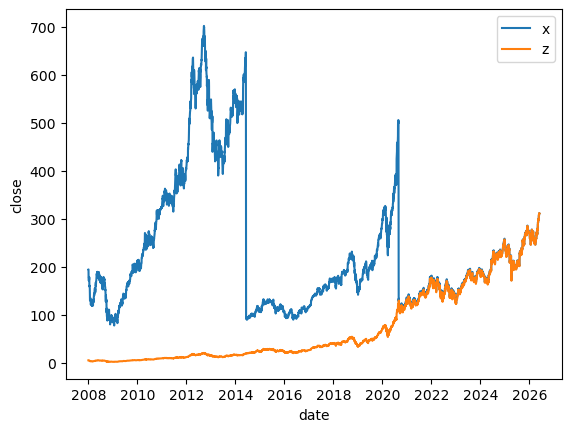

In [52]:
sns.lineplot(x = 'date', y = 'close', data = data, label = 'x')
sns.lineplot(x = 'date', y = 'adjClose', data = data, label = 'z')
plt.legend()
plt.show()